In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Load Amazon reviews dataset
df = pd.read_csv("https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv")

df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


In [2]:
print(df.shape)
print(df.isnull().sum())
print(df['Positive'].value_counts())

(20000, 2)
reviewText    0
Positive      0
dtype: int64
Positive
1    15233
0     4767
Name: count, dtype: int64


In [3]:
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = text.strip()
    return text

df['clean_review'] = df['reviewText'].apply(clean_text)
df[['reviewText', 'clean_review']].head()

,reviewText,clean_review
0,This is a one of the best apps acording to a b...,this is a one of the best apps acording to a b...
1,This is a pretty good version of the game for ...,this is a pretty good version of the game for ...
2,this is a really cool game. there are a bunch ...,this is a really cool game there are a bunch o...
3,"This is a silly game and can be frustrating, b...",this is a silly game and can be frustrating bu...
4,This is a terrific game on any pad. Hrs of fun...,this is a terrific game on any pad hrs of fun ...


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_review']
y = df['Positive']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train size:", X_train_tfidf.shape)
print("Test size:", X_test_tfidf.shape)

Train size: (16000, 5000)
Test size: (4000, 5000)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=200)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.89875
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       958
           1       0.91      0.97      0.94      3042

    accuracy                           0.90      4000
   macro avg       0.89      0.83      0.85      4000
weighted avg       0.90      0.90      0.89      4000



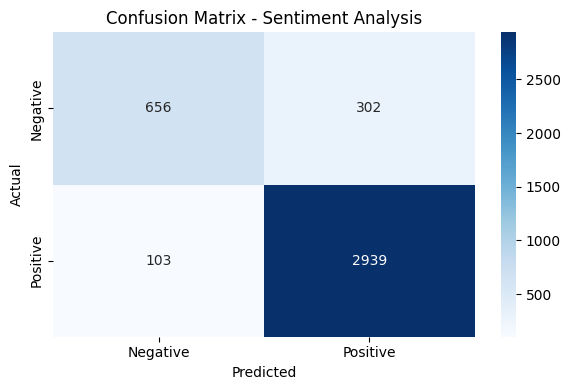

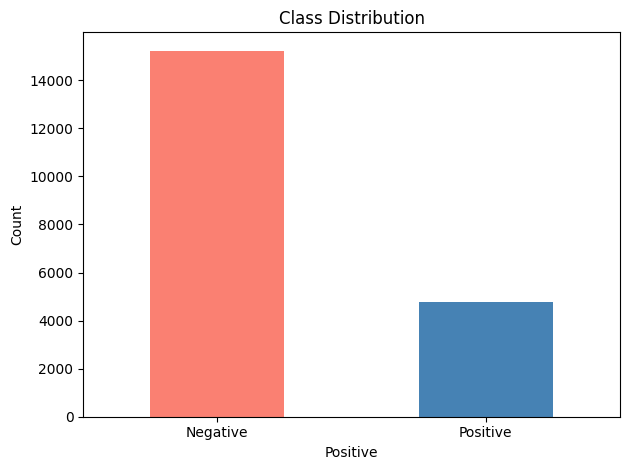

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix - Sentiment Analysis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Class distribution
df['Positive'].value_counts().plot(kind='bar', color=['salmon','steelblue'])
plt.title('Class Distribution')
plt.xticks([0,1], ['Negative','Positive'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()